In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Get SOC-level data

hypothesis:
1. Is the Philippines similar enough to the US?
2. Is there a relationship between the similarity to the US and usage of AIOE.

In [24]:
anthropic_df = pd.read_csv('../data/ai_measurements/release-2026-06-26/aei_claude_ai_2026-06-26.csv')

# get the rows where it is for the philippines and contains the SOC codes and for the latest month
anthropic_usage_df = anthropic_df.query(
    "category_name == 'soc_occupation' "
    "and metric_id == 'pct' "
    "and geo_level == 'country' "
    #"and (geo_level == 'global' or geo_level == 'country') "
    "and hierarchy_level == 0 "
    "and date_start == '2026-05-01' "
    "and date_end == '2026-06-01'"
).sort_values(by='value', ascending=False)

anthropic_usage_df = anthropic_usage_df[['value', 'geo_id', 'node_external_id']]

In [25]:
# Get Philippines, USA, and global usage rates.
phl_usage_df = anthropic_usage_df[
    anthropic_usage_df.geo_id == 'PHL'
]
usa_usage_df = anthropic_usage_df[
    anthropic_usage_df.geo_id == 'USA'
]
global_usage_df = anthropic_usage_df[
    anthropic_usage_df.geo_id == 'GLOBAL'
]

# Merge everything.
first_merge = global_usage_df.merge(
    phl_usage_df,
    how='left',
    on='node_external_id',
    suffixes=(' GLOBAL', ' PHL'),
)

second_merge = (
    first_merge
    .merge(
        usa_usage_df,
        how='left',
        on='node_external_id',
    )
    .rename(columns={'value': 'value USA'})
    .fillna(0)
)

usages_df = second_merge[
    ['node_external_id', 'value GLOBAL', 'value PHL', 'value USA']
].copy()

In [26]:
def raw_cos(a, b):
    """Compute the raw cosine"""
    # Only consider indices where both a and b are non-null
    common_idx = a.notna() & b.notna()
    
    # Return 0 if no common ratings
    if common_idx.sum() == 0:
        return 0
    
    # Extract the common ratings
    v1 = a[common_idx].values
    v2 = b[common_idx].values
    
    # Compute cosine similarity
    numerator = np.dot(v1, v2)
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    
    if denom == 0:
        return 0
    
    return numerator / denom

def compute_raw_similarity_matrix(usage_df):
    """
    Compute pairwise cosine similarity between countries.
    Parameters
    ----------
    usage_df : pd.DataFrame
        The country-SOC code usage matrix with country as rows,
        SOC codes as columns, and Anthropic usage as values. Missing ratings
        should be represented as NaN.
    Returns
    -------
    pd.DataFrame
        A completed utility matrix with missing values filled in
        by predicted ratings.
    """
    # Compute cosine similarity matrix
    n = len(usage_df)
    cosine_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            cosine_matrix[i, j] = raw_cos(
                usage_df.iloc[i],
                usage_df.iloc[j]
            )
    sims = pd.DataFrame(
        cosine_matrix,
        index=usage_df.index,
        columns=usage_df.index
    )

    return sims

In [27]:
# create a pivot table where countries are rows, SOC codes as columns, 
# and Anthropic usage as values. Missing ratings should be represented as NaN.
country_usage_df = anthropic_usage_df.pivot(
    index='geo_id',
    columns='node_external_id',
    values='value',
)

# get how similar each country is to the US
similarity_matrix = compute_raw_similarity_matrix(country_usage_df)
usa_similarity_contest = similarity_matrix['USA'].sort_values()

In [28]:
country_usage_df.loc['PHL']

node_external_id
11-1011.00    0.14
11-1021.00    0.22
11-1031.00     NaN
11-2011.00    1.06
11-2021.00    0.44
              ... 
53-6051.07    0.11
53-6061.00     NaN
53-7062.00     NaN
53-7064.00     NaN
53-7065.00     NaN
Name: PHL, Length: 628, dtype: float64

In [29]:
usa_similarity_contest[-20:]

geo_id
ARE    0.971702
LUX    0.971833
EST    0.973704
AUT    0.974199
FRA    0.974757
NZL    0.976148
PRI    0.976983
AUS    0.978123
FIN    0.978775
ISL    0.979252
JPN    0.981044
CHE    0.981419
SWE    0.982532
DEU    0.983449
SGP    0.986336
IRL    0.986654
GBR    0.987236
NLD    0.989961
CAN    0.996246
USA    1.000000
Name: USA, dtype: float64

<Axes: ylabel='geo_id'>

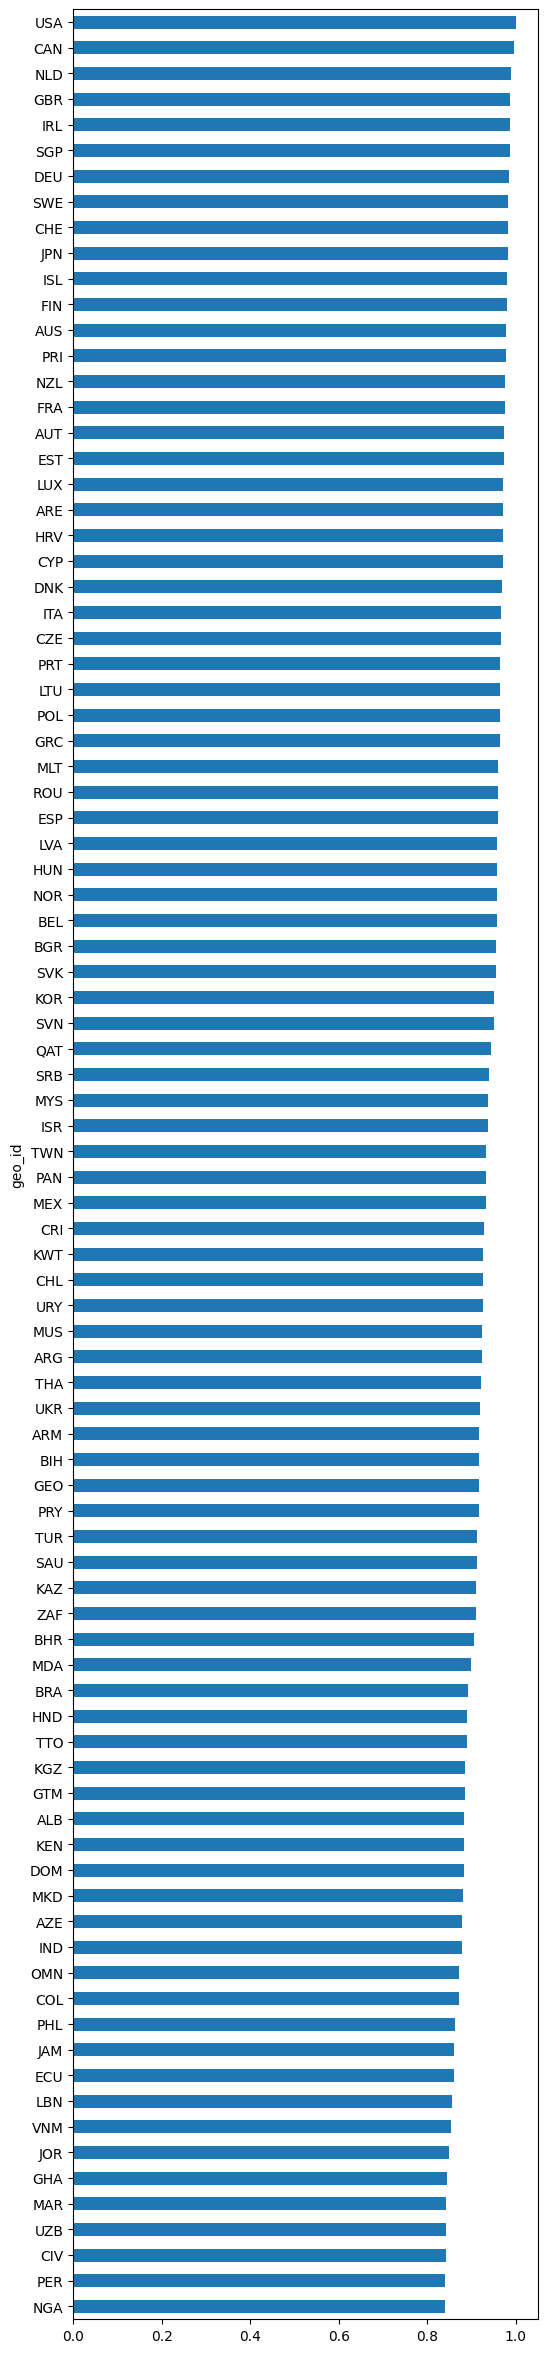

In [30]:
usa_similarity_contest[-90:].plot(kind='barh', figsize=(6, 30))

In [36]:
aioe = pd.read_json(
    '../data/ai_measurements/soc_aioe.json',
    typ='series'
).to_dict()

aioe = pd.read_json(
    '../data/ai_measurements/soc_complementarity.json',
    typ='series'
).to_dict()

# partial_anthropic_phl_soc_df = complete_anthropic_phl_soc_df.join(
#     aioe.rename('AIOE')
# )

# partial_anthropic_aioe_soc_df = partial_anthropic_phl_soc_df.join(
#     aioe.rename('AIOE')
# )

In [ ]:
country_correl_aioe_anthropic = {}

country = country_usage_df.iloc[0]

for _, country in country_usage_df.iterrows():
    country = country.dropna().reset_index() 
    country_code = country.columns[1]
    country.columns = ['SOC', 'Anthropic']
    country['AIOE'] = country['SOC'].map(aioe)
    correlation = country['Anthropic'].corr(country['AIOE'])
     

country_correl_aioe_anthropic = pd.Series(country_correl_aioe_anthropic).sort_index()
country_correl_aioe_anthropic

AGO   -0.276027
ALB   -0.127025
ARE   -0.288224
ARG   -0.288469
ARM   -0.096263
         ...   
UZB   -0.295574
VNM   -0.304924
ZAF   -0.300955
ZMB   -0.097444
ZWE    0.104447
Length: 121, dtype: float64

Text(0, 0.5, 'Correlation between Complementarity and Anthropic Usage Rates')

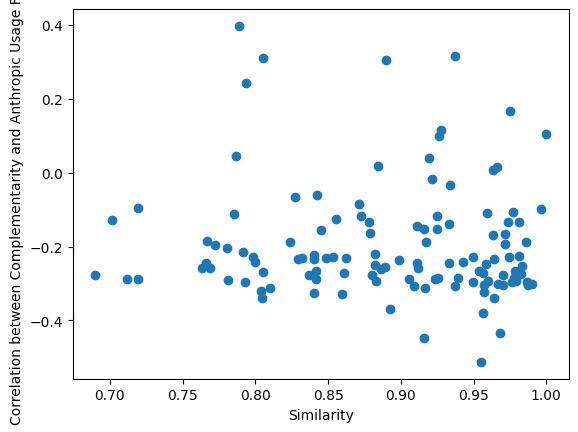

In [39]:
plt.scatter(usa_similarity_contest, country_correl_aioe_anthropic)
plt.xlabel('Similarity')
plt.ylabel('Correlation between Complementarity and Anthropic Usage Rates')

In [34]:
country_correl_aioe_anthropic[country_correl_aioe_anthropic > 0.3]

ZWE    0.322916
dtype: float64